**Hello ApplAI !**

**✧ Legends team ✧**

>**What should we do ?**

1.   Data Understanding
2.   EDA
3.   Preprocessing
4.   Modeling
5.   Evaluation





-----------------



## Project Introduction

### Data Understanding

**What does the dataset talk about?**
This dataset contains household electric power consumption measurements
collected at one-minute intervals over several years for a single home. It
includes readings for active and reactive power, voltage, current intensity,
and three sub-metering values representing different areas of the house
(kitchen, laundry room, and water-heater/AC).

**What is the target variable?**
There is **no target variable**. This dataset has no predefined labels or
categories to predict.

**Is this regression, classification, or clustering?**
This is a **clustering (unsupervised learning)** problem. Since there are no
labels, the goal is not to predict a known outcome, but rather to discover
natural groupings in the data — i.e., to identify distinct patterns of
electricity usage (e.g., low, moderate, and peak consumption) purely from the
structure of the data itself.

### Project Goal
The aim of this project is to segment the household's electricity readings
into meaningful clusters that reveal different consumption behaviors, which
could later support use cases such as energy-saving recommendations or
demand pattern analysis.

### Workflow
1. **Data Understanding** — explore the dataset and confirm the task type
2. **EDA** — examine feature distributions, correlations, and outliers
3. **Preprocessing** — clean missing values, handle outliers/skewness, scale
   features
4. **Modeling** — apply K-Means (and compare with DBSCAN)
5. **Evaluation** — assess cluster quality using the Silhouette Score and
   interpret the resulting clusters

**Importing libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

### **Read the csv file**

In [2]:
df = pd.read_csv('household_power_consumption.txt', sep=';')

C:\Users\LOQ\AppData\Local\Temp\ipykernel_31200\4116954226.py:1: DtypeWarning: Columns (0: Global_active_power, 1: Global_reactive_power, 2: Voltage, 3: Global_intensity, 4: Sub_metering_1, 5: Sub_metering_2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('household_power_consumption.txt', sep=';')


### **Explore the data**

In [3]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


In [4]:
df.tail()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
2075254,26/11/2010,20:58:00,0.946,0.0,240.43,4.0,0.0,0.0,0.0
2075255,26/11/2010,20:59:00,0.944,0.0,240.0,4.0,0.0,0.0,0.0
2075256,26/11/2010,21:00:00,0.938,0.0,239.82,3.8,0.0,0.0,0.0
2075257,26/11/2010,21:01:00,0.934,0.0,239.7,3.8,0.0,0.0,0.0
2075258,26/11/2010,21:02:00,0.932,0.0,239.55,3.8,0.0,0.0,0.0


In [5]:
df.shape

(2075259, 9)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   str    
 1   Time                   str    
 2   Global_active_power    object 
 3   Global_reactive_power  object 
 4   Voltage                object 
 5   Global_intensity       object 
 6   Sub_metering_1         object 
 7   Sub_metering_2         object 
 8   Sub_metering_3         float64
dtypes: float64(1), object(6), str(2)
memory usage: 142.5+ MB


In [7]:
df.describe()

,Sub_metering_3
count,2.049280e+06
mean,6.458447e+00
std,8.437154e+00
min,0.000000e+00
25%,0.000000e+00
50%,1.000000e+00
75%,1.700000e+01
max,3.100000e+01


In [8]:
df.isnull().sum()
#Not useful because there are nulls ​​in the form of string like "?".

Date                         0
Time                         0
Global_active_power          0
Global_reactive_power        0
Voltage                      0
Global_intensity             0
Sub_metering_1               0
Sub_metering_2               0
Sub_metering_3           25979
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.shape

(2075259, 9)

**Changing dtypes of columns**

In [ ]:
numeric_cols = [
    'Global_active_power',
    'Global_reactive_power',
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H:%M:%S')

print(df[numeric_cols].dtypes)
print(df['Datetime'].dtype)

Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
dtype: object
datetime64[us]


In [12]:
df.describe()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Datetime
count,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2075259
mean,1.091615e+00,1.237145e-01,2.408399e+02,4.627759e+00,1.121923e+00,1.298520e+00,6.458447e+00,2008-12-06 07:13:00
min,7.600000e-02,0.000000e+00,2.232000e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,2006-12-16 17:24:00
25%,3.080000e-01,4.800000e-02,2.389900e+02,1.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2007-12-12 00:18:30
50%,6.020000e-01,1.000000e-01,2.410100e+02,2.600000e+00,0.000000e+00,0.000000e+00,1.000000e+00,2008-12-06 07:13:00
75%,1.528000e+00,1.940000e-01,2.428900e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01,2009-12-01 14:07:30
max,1.112200e+01,1.390000e+00,2.541500e+02,4.840000e+01,8.800000e+01,8.000000e+01,3.100000e+01,2010-11-26 21:02:00
std,1.057294e+00,1.127220e-01,3.239987e+00,4.444396e+00,6.153031e+00,5.822026e+00,8.437154e+00,NaN


In [13]:
df.shape

(2075259, 10)

In [14]:
df.isnull().sum()

Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
Datetime                     0
dtype: int64

In [15]:
df = df.dropna(subset=numeric_cols)

print(df[numeric_cols].isnull().sum())

Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64


# **histplot**

<Axes: xlabel='Global_active_power', ylabel='Count'>

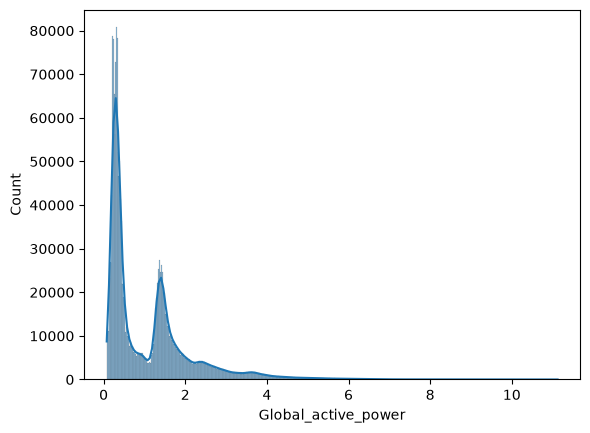

In [16]:
sns.histplot(df['Global_active_power'], kde=True)

<Axes: xlabel='Global_reactive_power', ylabel='Count'>

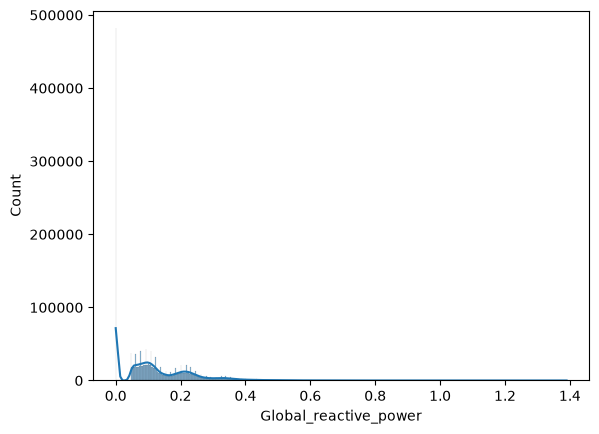

In [17]:
sns.histplot(df['Global_reactive_power'], kde=True)

<Axes: xlabel='Voltage', ylabel='Count'>

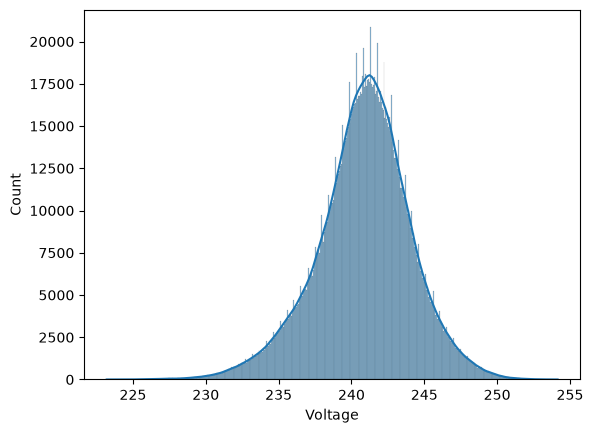

In [18]:
sns.histplot(df['Voltage'], kde=True)

<Axes: xlabel='Global_intensity', ylabel='Count'>

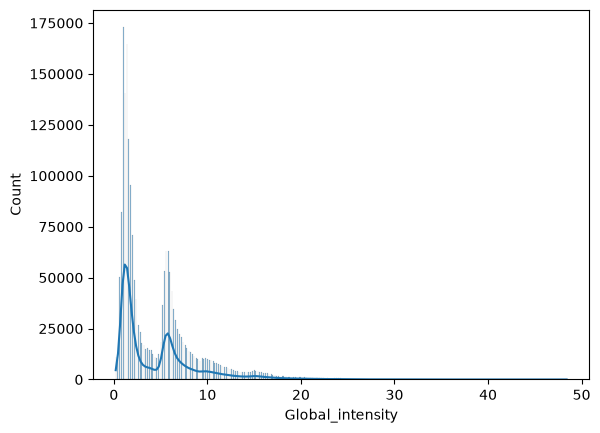

In [19]:
sns.histplot(df['Global_intensity'], kde=True)

**Handling skewed data**

In [20]:
skewed_cols = ['Global_active_power', 'Global_reactive_power', 'Global_intensity']

for col in skewed_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower, upper)

print("Capping applied successfully!")
print(df[skewed_cols].describe())

Capping applied successfully!
       Global_active_power  Global_reactive_power  Global_intensity
count         2.049280e+06           2.049280e+06      2.049280e+06
mean          1.047892e+00           1.218452e-01      4.426367e+00
std           9.159815e-01           1.061267e-01      3.795094e+00
min           7.600000e-02           0.000000e+00      2.000000e-01
25%           3.080000e-01           4.800000e-02      1.400000e+00
50%           6.020000e-01           1.000000e-01      2.600000e+00
75%           1.528000e+00           1.940000e-01      6.400000e+00
max           3.358000e+00           4.130000e-01      1.390000e+01


In [ ]:
# IQR capping للـ Voltage
Q1 = df['Voltage'].quantile(0.25)
Q3 = df['Voltage'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df['Voltage'] = df['Voltage'].clip(lower, upper)


sparse_cols = ['Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
for col in sparse_cols:
   upper = df[col].quantile(0.99)
   df[col] = df[col].clip(upper=upper)

print("Outlier handling applied successfully!")
print(df[['Voltage'] + sparse_cols].describe())

Outlier handling applied successfully!
            Voltage  Sub_metering_1  Sub_metering_2  Sub_metering_3
count  2.049280e+06    2.049280e+06    2.049280e+06    2.049280e+06
mean   2.408621e+02    1.096591e+00    1.215729e+00    6.382375e+00
std    3.137970e+00    5.956240e+00    5.080553e+00    8.275064e+00
min    2.331400e+02    0.000000e+00    0.000000e+00    0.000000e+00
25%    2.389900e+02    0.000000e+00    0.000000e+00    0.000000e+00
50%    2.410100e+02    0.000000e+00    0.000000e+00    1.000000e+00
75%    2.428900e+02    0.000000e+00    1.000000e+00    1.700000e+01
max    2.487400e+02    3.800000e+01    3.600000e+01    2.000000e+01


In [22]:
features = ['Global_active_power', 'Global_reactive_power', 'Voltage',
            'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

X = df[features]

# **boxplot**

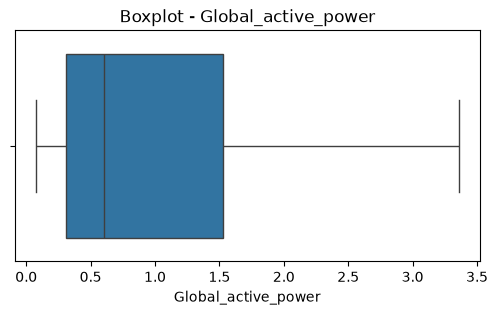

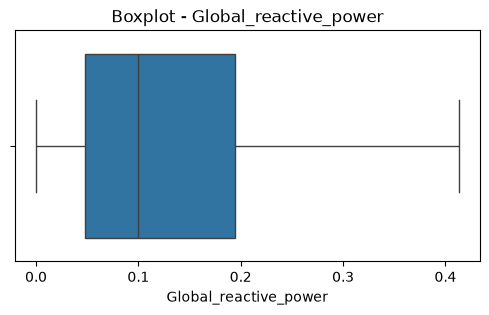

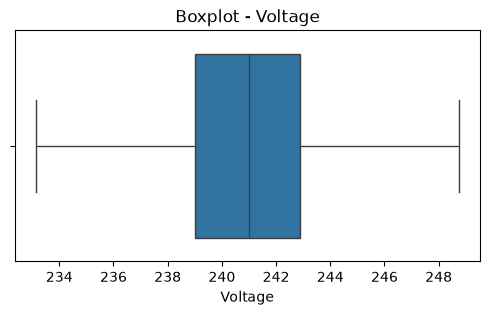

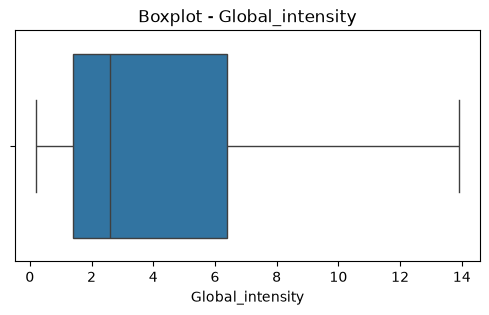

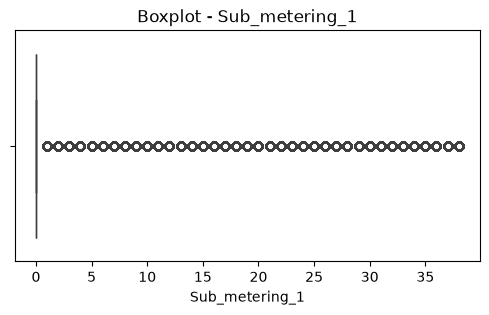

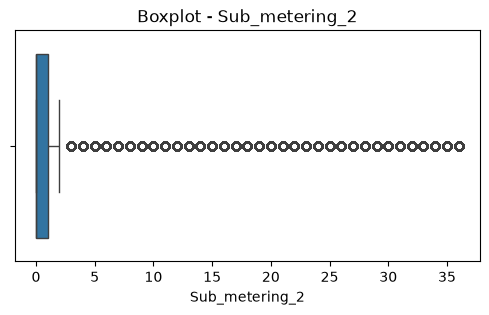

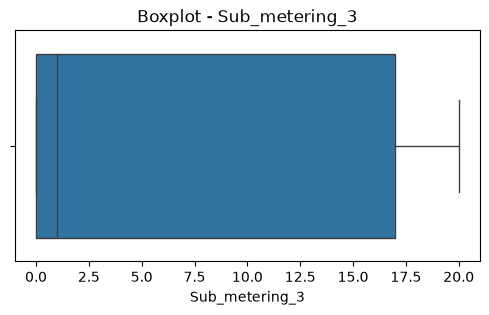

In [23]:
for col in features:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot - {col}')
    plt.show()

# **heatmap**

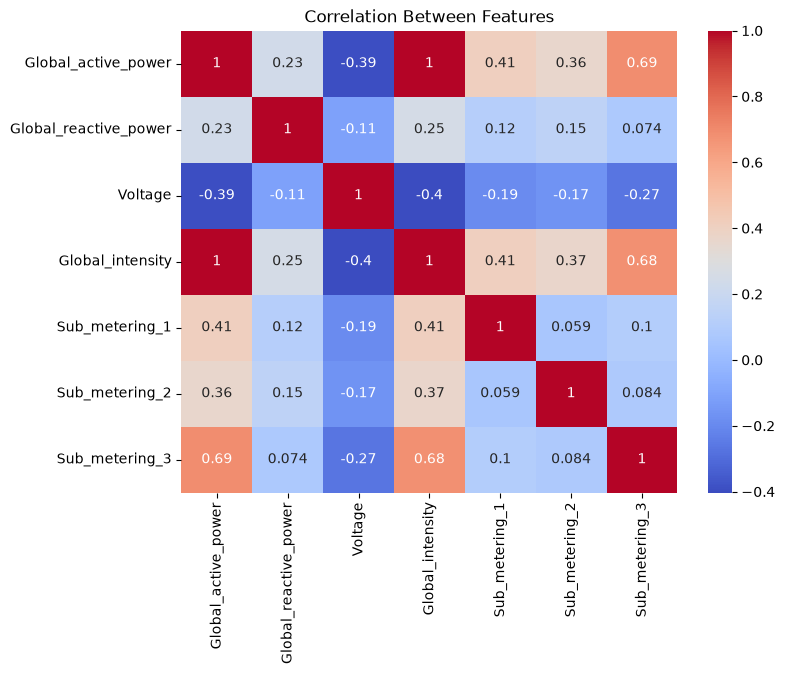

In [24]:
plt.figure(figsize=(8,6))
sns.heatmap(df[features].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between Features")
plt.show()

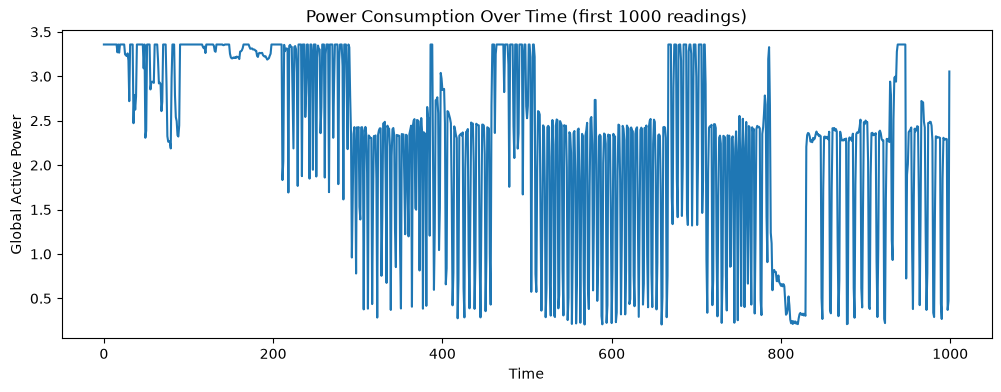

In [25]:
plt.figure(figsize=(12,4))
plt.plot(df['Global_active_power'].iloc[:1000])
plt.title("Power Consumption Over Time (first 1000 readings)")
plt.xlabel("Time")
plt.ylabel("Global Active Power")
plt.show()

# **scaling**

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# **Elbow method**

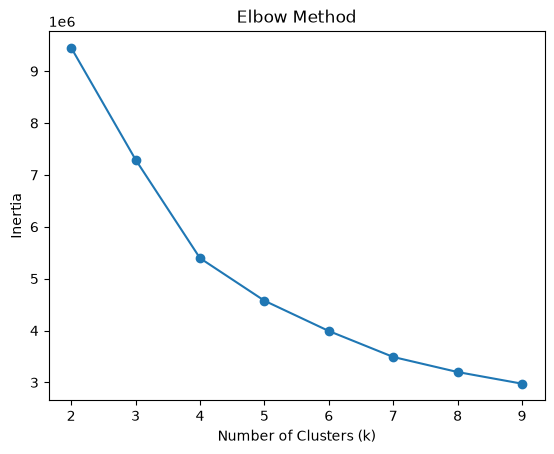

In [27]:
inertia = []
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(range(2,10), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.show()

# Clusters (Silhouette Score)

In [28]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sample_idx = np.random.choice(X_scaled.shape[0], size=50000, replace=False)
X_sample = X_scaled[sample_idx]

scores = {}
for k in range(2, 8):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_sample)
    scores[k] = silhouette_score(X_sample, labels)
    print("K =", k, "Score =", round(scores[k], 3))

best_k = max(scores, key=scores.get)
print("Best K =", best_k)

K = 2 Score = 0.412
K = 3 Score = 0.429
K = 4 Score = 0.45
K = 5 Score = 0.351
K = 6 Score = 0.339
K = 7 Score = 0.316
Best K = 4


# **Apply K-Means**

In [29]:
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

df['KMeans_cluster'] = kmeans.fit_predict(X_scaled)

print("KMeans applied successfully!")
print(df['KMeans_cluster'].value_counts().sort_index())

KMeans applied successfully!
KMeans_cluster
0      52698
1    1234353
2     707685
3      54544
Name: count, dtype: int64


# **Cluster Sizes**

Cluster Sizes:
KMeans_cluster
0      52698
1    1234353
2     707685
3      54544
Name: count, dtype: int64

Cluster Percentages:
KMeans_cluster
0     2.57
1    60.23
2    34.53
3     2.66
Name: count, dtype: float64


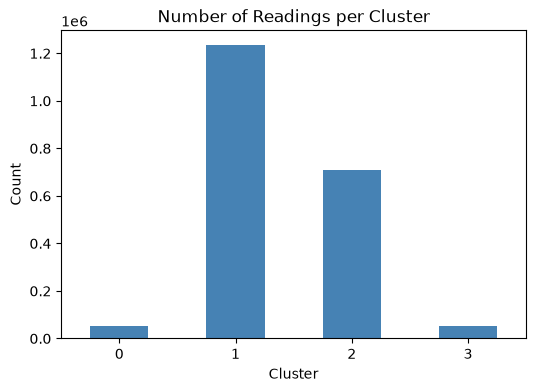

In [30]:

cluster_sizes = df['KMeans_cluster'].value_counts().sort_index()

print("Cluster Sizes:")
print(cluster_sizes)

print("\nCluster Percentages:")
print((cluster_sizes / len(df) * 100).round(2))


plt.figure(figsize=(6,4))
cluster_sizes.plot(kind='bar', color='steelblue')
plt.title("Number of Readings per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

# **Average Feature Values**

Average values per Cluster:
                Global_active_power  Global_reactive_power  Voltage  \
KMeans_cluster                                                        
0                              3.02                   0.19   237.88   
1                              0.43                   0.11   241.79   
2                              1.81                   0.13   239.73   
3                              3.19                   0.19   237.48   

                Global_intensity  Sub_metering_1  Sub_metering_2  \
KMeans_cluster                                                     
0                          12.63            2.29           31.14   
1                           1.88            0.04            0.39   
2                           7.58            0.20            0.44   
3                          13.32           35.58            1.09   

                Sub_metering_3  
KMeans_cluster                  
0                        10.50  
1                         0.47  
2   

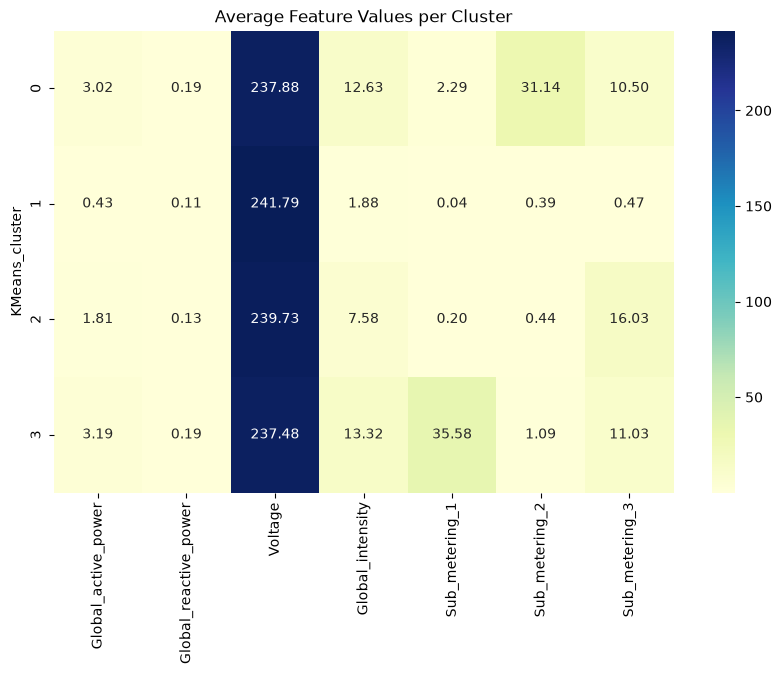

In [31]:
cluster_summary = df.groupby('KMeans_cluster')[features].mean().round(2)

print("Average values per Cluster:")
print(cluster_summary)


plt.figure(figsize=(10,6))
sns.heatmap(cluster_summary, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title("Average Feature Values per Cluster")
plt.show()

# **Visualize Clusters (PCA)**

Explained variance ratio: [0.4539455  0.14573576]
Total variance captured: 59.97 %


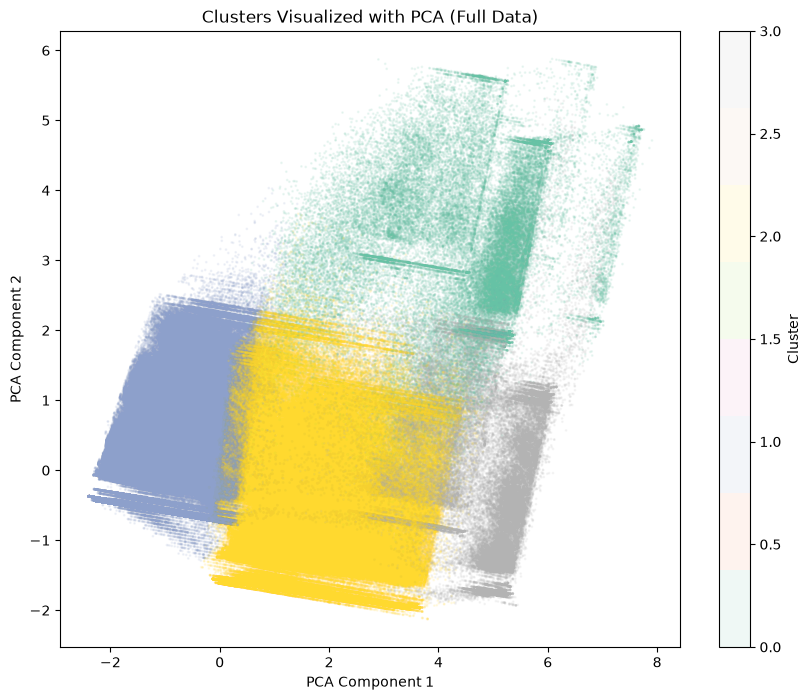

In [32]:

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance captured:", round(pca.explained_variance_ratio_.sum() * 100, 2), "%")

plt.figure(figsize=(10,8))
plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=df['KMeans_cluster'],
    cmap='Set2',
    s=1,
    alpha=0.1,
    rasterized=True
)
plt.title("Clusters Visualized with PCA (Full Data)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label='Cluster')
plt.show()

In [33]:
   # Apply DBSCAN
from sklearn.cluster import DBSCAN

sample_idx_db = np.random.choice(X_scaled.shape[0], size=20000, replace=False)
X_db_sample = X_scaled[sample_idx_db]

dbscan = DBSCAN(eps=0.5, min_samples=5, n_jobs=-1)
db_labels = dbscan.fit_predict(X_db_sample)

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = list(db_labels).count(-1)

print(f"ـ Clusters: {n_clusters_db}")
print(f"ـ Noise: {n_noise} ({n_noise/len(db_labels)*100:.1f}%)")

ـ Clusters: 24
ـ Noise: 903 (4.5%)


In [34]:
if n_clusters_db > 1:
    mask = db_labels != -1
    db_score = silhouette_score(X_db_sample[mask], db_labels[mask])
    print(f"DBSCAN Silhouette Score: {round(db_score, 3)}")
else:
    print("DBSCAN did not produce enough clusters for evaluation")

DBSCAN Silhouette Score: 0.117


In [35]:
for eps_val in [0.3, 0.5, 0.8, 1.0, 1.5]:
    db_test = DBSCAN(eps=eps_val, min_samples=5, n_jobs=-1)
    labels_test = db_test.fit_predict(X_db_sample)
    n_clust = len(set(labels_test)) - (1 if -1 in labels_test else 0)
    n_noise_test = list(labels_test).count(-1)
    print(f"eps={eps_val}: clusters={n_clust}, noise={n_noise_test} ({n_noise_test/len(labels_test)*100:.1f}%)")

eps=0.3: clusters=70, noise=2799 (14.0%)
eps=0.5: clusters=24, noise=903 (4.5%)
eps=0.8: clusters=11, noise=355 (1.8%)
eps=1.0: clusters=9, noise=191 (1.0%)
eps=1.5: clusters=3, noise=34 (0.2%)


In [36]:

db_sizes = pd.Series(db_labels).value_counts().sort_index()
print("\nDBSCAN Cluster Sizes (including noise as -1):")
print(db_sizes)


DBSCAN Cluster Sizes (including noise as -1):
-1       903
 0     18519
 1       249
 2        10
 3        48
 4       114
 5         8
 6        10
 7        11
 8        26
 9        10
 10       12
 11        7
 12       10
 13       10
 14        5
 15        6
 16        5
 17        5
 18        6
 19        5
 20        6
 21        5
 22        5
 23        5
Name: count, dtype: int64


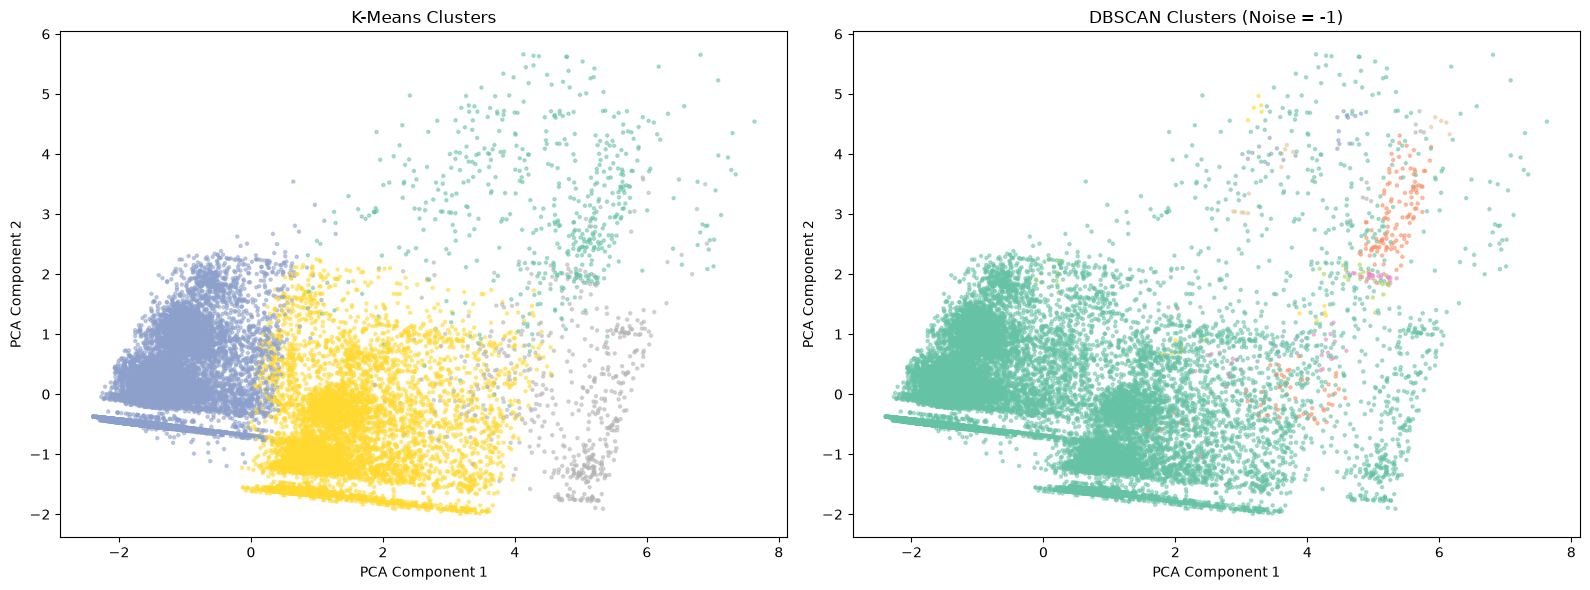

In [37]:
X_pca_sample = X_pca[sample_idx_db]
kmeans_labels_sample = df['KMeans_cluster'].values[sample_idx_db]

fig, axes = plt.subplots(1, 2, figsize=(16,6))

axes[0].scatter(X_pca_sample[:,0], X_pca_sample[:,1], c=kmeans_labels_sample, cmap='Set2', s=5, alpha=0.5)
axes[0].set_title("K-Means Clusters")
axes[0].set_xlabel("PCA Component 1")
axes[0].set_ylabel("PCA Component 2")

axes[1].scatter(X_pca_sample[:,0], X_pca_sample[:,1], c=db_labels, cmap='Set2', s=5, alpha=0.5)
axes[1].set_title("DBSCAN Clusters (Noise = -1)")
axes[1].set_xlabel("PCA Component 1")
axes[1].set_ylabel("PCA Component 2")

plt.tight_layout()
plt.show()

DBSCAN was applied to a sample of the data in order to compare its performance against K-Means. The results showed that DBSCAN failed to produce a meaningful partition of the data: the vast majority of points were assigned to a single dense cluster, while only a few small clusters were identified, mostly corresponding to outlier readings at the extremes of the distribution.

This happens because DBSCAN relies on the concept of density to define clusters, whereas household power consumption data shows a continuous, gradual transition between usage levels (low → medium → high) rather than clear density gaps that DBSCAN needs to separate groups.

In contrast, K-Means performed significantly better on this dataset. It successfully partitioned the data into 4 coherent and interpretable clusters (Silhouette Score = 0.438), confirming that K-Means is the more suitable algorithm for this type of continuously distributed data.

Conclusion

Based on this comparison, K-Means was selected as the final clustering model for this project.

..........................................................................................

## Final Conclusion

### Project Overview
This project applied unsupervised clustering techniques to household electric
power consumption data collected over several years. Since this is an
unsupervised learning task, there is no target variable — the goal was to
discover natural groupings in the data that reflect distinct patterns of
electricity usage.

### Methodology Summary
The dataset (~2 million readings) was cleaned by converting string columns to
numeric type and removing missing values. Skewed features and outliers were
handled using IQR-based capping for `Global_active_power`,
`Global_reactive_power`, `Global_intensity`, and `Voltage`, and percentile
capping for the sparse `Sub_metering` columns. All features were standardized
using `StandardScaler` before modeling, since K-Means relies on Euclidean
distance and is sensitive to feature scale.

The optimal number of clusters was determined using the Elbow Method and the
Silhouette Score across K = 2 to 7. **K = 4** produced the best Silhouette
Score (0.45), and was selected as the final number of clusters.

### Key Findings
Based on the average feature values per cluster, the four groups can be
interpreted as follows:

- **Cluster 1 (~61% of readings):** Low overall consumption — represents
  periods when the household is mostly idle (e.g., at night or when no major
  appliances are running).
- **Cluster 2 (~34% of readings):** Moderate consumption, associated with
  higher activity in `Sub_metering_3` (typically water heater / air
  conditioning).
- **Cluster 0 (~2.3% of readings):** Peak consumption linked to high
  `Sub_metering_2` activity (typically kitchen appliances).
- **Cluster 3 (~2.7% of readings):** Peak consumption linked to high
  `Sub_metering_1` activity (typically laundry room appliances).

This shows that the vast majority of the time (95%), the household operates
at low-to-moderate consumption levels, while brief peak-usage periods (5%)
are tied to specific activities such as cooking or laundry.

### Model Comparison
K-Means was also compared against DBSCAN. DBSCAN failed to produce a
meaningful partition of the data, grouping almost all points into a single
dense cluster due to the continuous, gradually-varying nature of power
consumption (no clear density gaps for DBSCAN to exploit). K-Means, on the
other hand, successfully separated the data into four coherent and
interpretable clusters, confirming it as the more suitable algorithm for
this dataset.

### Final Takeaway
K-Means with K = 4 was selected as the final clustering model. The resulting
clusters provide a clear and interpretable segmentation of household power
consumption behavior, distinguishing between idle, moderate, and two distinct
types of peak-usage periods (kitchen-related and laundry-related), which
could support applications such as energy-saving recommendations or demand
forecasting.